# FFS: pełny przebieg krok po kroku

Kolejność analizy w `pyaraucaria.ffs.FFS`:

1. maski wykluczające (saturacja, NaN, maski z kalibracji),
2. statystyki klatki (`mk_stats`),
3. mapa tła (`sky_map`),
4. maska progowa (`mk_threshold_mask`),
5. linie, czyli satelity (`find_lines`),
6. gwiazdy (`find_stars`, `star_info`, `calc_star_stats`).

Wyniki trafiają do trzech słowników o rozmiarze obrazu albo tabel:
`ffs.stats` (liczby), `ffs.maps` (mapy w ADU), `ffs.masks` (maski bool).
Każdy ma swój opis w `*_description`. Maski, których nazwy są w `ffs.exclude`, są pomijane przez kolejne kroki
(`ffs.bad_mask()` to ich suma).

Dla porównania `calc_frame_fwhm()` robi to wszystko jednym wywołaniem (patrz `ffs_quick.ipynb`).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))   # pyaraucaria z tego repozytorium, nie z instalacji w kernelu
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from pyaraucaria.ffs import FFS
import pyaraucaria
print("pyaraucaria z:", os.path.dirname(pyaraucaria.__file__))

DATA = os.path.expanduser("~/work/data/fits_examples")
# kolory masek: stala kolejnosc (niebieski, pomaranczowy, morski, zolty)
C1, C2, C3, C4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"


def show(ax, img, title="", lo=1, hi=99.5, cmap="gray"):
    """Obraz w skali percentyli lo..hi."""
    vmin, vmax = np.nanpercentile(img, [lo, hi])
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, origin="lower", interpolation="nearest")
    ax.set_title(title)


def overlay(ax, mask, color, label):
    """Polprzezroczysta maska jednego koloru (z etykieta do legendy)."""
    rgba = np.zeros(mask.shape + (4,))
    rgba[mask] = list(int(color[i:i + 2], 16) / 255 for i in (1, 3, 5)) + [0.8]
    ax.imshow(rgba, origin="lower", interpolation="nearest")
    ax.plot([], [], "s", color=color, label=f"{label} ({int(mask.sum())} px)")


pyaraucaria z: /Users/mgorski/work/src/pyaraucaria/pyaraucaria


## 0. Klatka

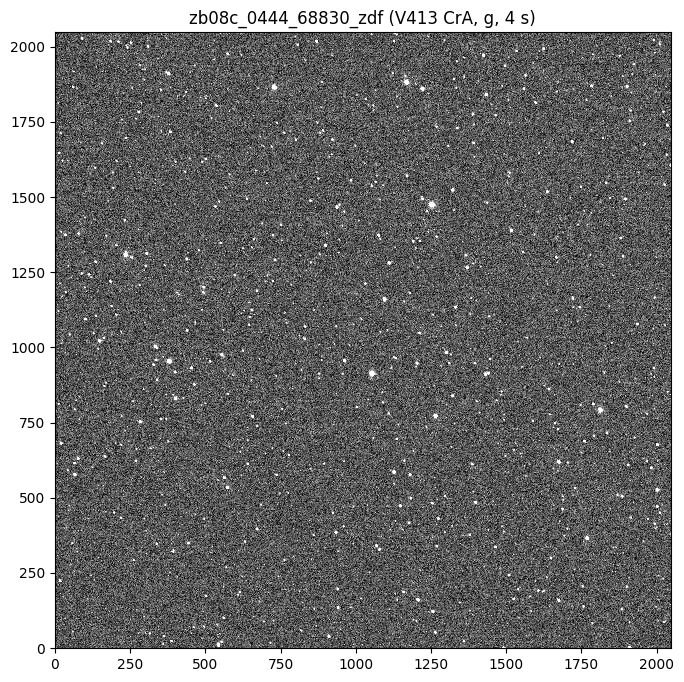

In [2]:
image = fits.getdata(os.path.join(DATA, "zb08c_0444_68830_zdf.fits")).astype(float)
ffs = FFS(image)
ffs.saturation = 20000            # celowo nisko, zeby bylo widac maske saturacji

fig, ax = plt.subplots(figsize=(8, 8))
show(ax, image, "zb08c_0444_68830_zdf (V413 CrA, g, 4 s)")
plt.show()

## 1. Maski wykluczające

`mk_saturation_mask()` zaznacza piksele `>= ffs.saturation`. Możesz podać prawdziwy próg saturacji albo niższy,
np. granicę liniowości detektora. Piksele `NaN` i `inf` trafiają do `masks["nonfinite"]` już w konstruktorze.
Obie maski są dopisywane do `ffs.exclude`.

In [3]:
ffs.mk_saturation_mask()
print("exclude:", sorted(ffs.exclude))
for name in ffs.masks:
    print(f"{name:12s} {ffs.masks[name].sum():8d} px   {ffs.masks_description[name]}")

exclude: ['saturation']
saturation          3 px   Saturated pixels (value >= 20000 ADU)


## 2. Statystyki klatki: `mk_stats()`

In [4]:
ffs.mk_stats()
for key, value in ffs.stats["frame"].items():
    print(f"{key:14s} {value:12.3f}   {ffs.stats_description['frame'][key]}")

min                 -52.315   Minimal pixel value in the image
max               22994.221   Maximum pixel value in the image
mean                  9.283   Mean pixel value (arithmetic average)
median                8.026   Median pixel value (robust background estimator)
rms                  58.938   Standard deviation of pixel values
q_sigma_lower         7.640   Lower 1-sigma estimate from 50% - 15.9% quantile
q_sigma_upper         8.178   Upper 1-sigma estimate from 84.1% - 50% quantile
q_sigma               7.909   Robust sigma estimated from 15.9–84.1% quantiles
noise                 2.833   Expected total noise (Poisson + read noise)
n_bad                 3.000   Number of excluded pixels (bad_mask); other statistics except min/max use only the remaining pixels


`min` i `max` są liczone ze wszystkich skończonych pikseli, żeby było widać saturację.
Pozostałe statystyki pomijają `bad_mask()`.

## 3. Mapa tła: `sky_map()`

Mediany w `n_segments × n_segments` segmentach, interpolowane liniowo po trójkątach (Delaunay).
Poza otoczką środków segmentów, czyli przy brzegach, wstawiana jest wartość najbliższego segmentu.
Gdy tło ma silną strukturę (winietowanie we flatach), zwiększ `n_segments`.

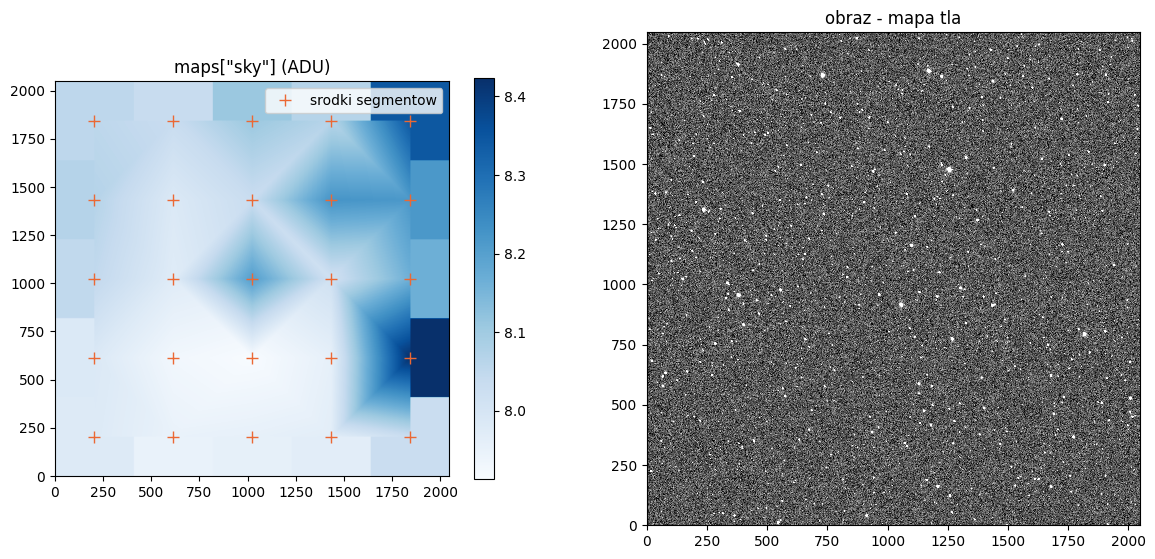

Sky background map: linear interpolation (Delaunay triangulation) of segment medians; outside the convex hull of segment centres filled with the nearest segment median


In [14]:
ffs.sky_map(n_segments=5)
sky = ffs.maps["sky"]

fig, axs = plt.subplots(1, 2, figsize=(14, 6.5))
im = axs[0].imshow(sky, origin="lower", cmap="Blues")
axs[0].plot(ffs.stats["sky"]["surface_x"], ffs.stats["sky"]["surface_y"], "+", color=C2, ms=8,
            label="srodki segmentow")
axs[0].set_title('maps["sky"] (ADU)'); axs[0].legend(loc="upper right")
fig.colorbar(im, ax=axs[0], shrink=0.8)
show(axs[1], image - sky, "obraz - mapa tla")
plt.show()
print(ffs.maps_description["sky"])

## 4. Maska progowa: `mk_threshold_mask()`

Piksele powyżej `tło + nsigma · sigma`. Po `sky_map()` tłem jest mapa tła, a sigma pochodzi z residuum
`obraz - tło`. Sama `q_sigma` całej klatki zawierałaby też rozrzut gradientu tła. Ta maska jest wejściem
do detekcji linii.

Pixels above sky map + 3 * sigma (sigma = 8.01 ADU, quantile-based; excluding bad_mask; input mask for line detection)


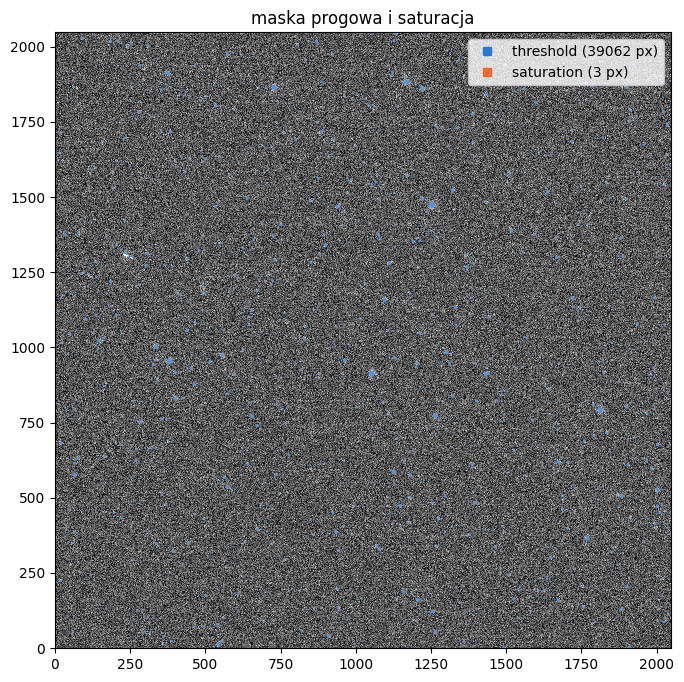

In [15]:
ffs.mk_threshold_mask(nsigma=3)
print(ffs.masks_description["threshold"])

fig, ax = plt.subplots(figsize=(8, 8))
show(ax, image, "maska progowa i saturacja")
overlay(ax, ffs.masks["threshold"], C1, "threshold")
overlay(ax, ffs.masks["saturation"], C2, "saturation")
ax.legend(loc="upper right")
plt.show()

## 5. Linie (satelity): `find_lines()`

Transformata Hougha maski progowej. Kandydat jest linią, jeśli wzdłuż niej piksele maski tworzą ciągły odcinek
(przerwy `<= max_gap`, długość `>= 10·fwhm`, zajętość `>= min_fill`). Piksele z `bad_mask()`, np. nasycona
gwiazda na trasie smugi, mostkują przerwy. Wynik:
`ffs.lines` (tabela z końcami odcinków), `masks["lines"]` (dopisana do `exclude`).

In [16]:
ffs.find_lines()
print(len(ffs.lines), "linii")
ffs.lines

1 linii


val,rho,theta,x0,y0,x1,y1
float64,float64,float64,float64,float64,float64,float64
100.0,1281.0,1.1208142507534764,266.32324208994527,1293.9713794063223,226.70322655540622,1313.1091527627734


Na tej klatce jest jedna krótka „linia” na jasnej gwieździe. To fałszywe wykrycie: przy domyślnych
parametrach `find_lines` czasem bierze jasne gwiazdy (pary gwiazd, spajki) za krótkie odcinki. Jest to do poprawy.

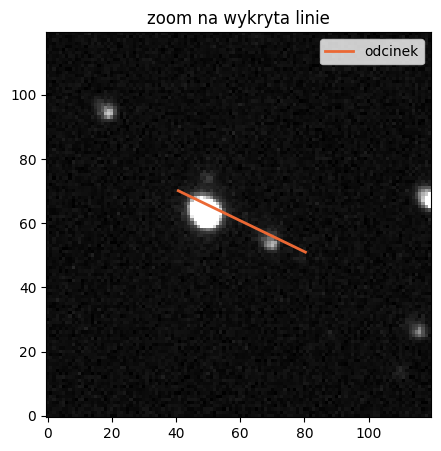

In [17]:
if len(ffs.lines):
    r = ffs.lines[0]
    xc, yc = int((r["x0"] + r["x1"]) / 2), int((r["y0"] + r["y1"]) / 2)
    y0, y1, x0, x1 = max(0, yc - 60), yc + 60, max(0, xc - 60), xc + 60
    fig, ax = plt.subplots(figsize=(5, 5))
    show(ax, image[y0:y1, x0:x1], "zoom na wykryta linie")
    ax.plot([r["x0"] - x0, r["x1"] - x0], [r["y0"] - y0, r["y1"] - y0], color=C2, lw=2, label="odcinek")
    ax.legend(loc="upper right")
    plt.show()

Prawdziwe smugi na klatce syntetycznej (gwiazdy, gradient tła, trzy smugi, w tym jedna przez nasyconą gwiazdę):

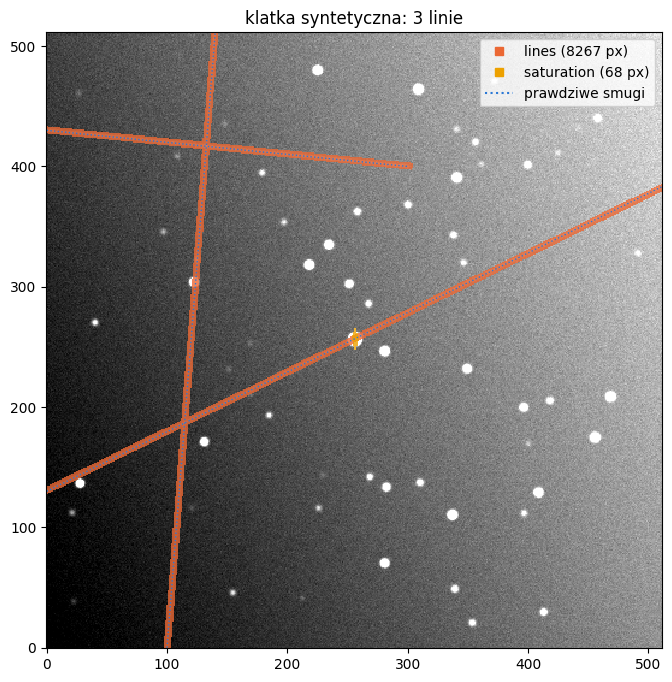

x0,y0,x1,y1,val,theta,rho
float64,float64,float64,float64,float64,float64,float64
1.2579866830319233,131.02830789377276,510.8546598985432,381.8972590369611,432.0,-1.1133363439037514,-117.0
100.31913256749127,0.2676581889565899,139.78684597387706,510.744199862001,313.0,-0.07716192482501243,100.0
301.11304160890114,400.1436444241445,-0.39707786223731745,430.15444009003477,295.0,1.471588137734166,428.0


In [18]:
from tests.ffs_synth import make_frame, star_field

stars = star_field(n=60, seed=5) + [dict(x=256.4, y=256.2, flux=4e6, fwhm=4.0)]
trails = [dict(x0=0, y0=130, x1=511, y1=383, flux=150, width=2.5),
          dict(x0=100, y0=0, x1=140, y1=511, flux=120, width=2.5),
          dict(x0=0, y0=430, x1=300, y1=400, flux=200, width=2.5)]
synth = make_frame(stars=stars, sky=1000, sky_gradient=(1.0, 0.5), saturation=45000, lines=trails, seed=6).image

s = FFS(synth)
s.saturation = 45000
s.mk_saturation_mask(); s.mk_stats(); s.sky_map(); s.mk_threshold_mask(); s.find_lines()

fig, ax = plt.subplots(figsize=(8, 8))
show(ax, synth, f"klatka syntetyczna: {len(s.lines)} linie")
overlay(ax, s.masks["lines"], C2, "lines")
overlay(ax, s.masks["saturation"], C4, "saturation")
for t in trails:
    ax.plot([t["x0"], t["x1"]], [t["y0"], t["y1"]], ":", color=C1, lw=1)
ax.plot([], [], ":", color=C1, label="prawdziwe smugi")
ax.legend(loc="upper right")
plt.show()
s.lines["x0", "y0", "x1", "y1", "val", "theta", "rho"]

### `FFS.line_to_mask`: z (ρ, θ) do pikseli

Niezależna metoda statyczna, np. do rysowania w FitsView. Konwencja: `x·cos θ + y·sin θ = ρ`, x to kolumna,
y to wiersz. Z końcami odcinka maluje tylko odcinek, a bez nich całą linię przez kadr.

In [10]:
lengths = np.hypot(s.lines["x1"] - s.lines["x0"], s.lines["y1"] - s.lines["y0"])
r = s.lines[int(np.argmin(lengths))]          # najkrotsza linia: odcinek krotszy niz przekatna kadru
segment = FFS.line_to_mask(synth.shape, r["rho"], r["theta"], 3.0, r["x0"], r["y0"], r["x1"], r["y1"])
whole = FFS.line_to_mask(synth.shape, r["rho"], r["theta"], 3.0)
for name, m in (("odcinek", segment), ("cala linia przez kadr", whole)):
    ys, xs = np.nonzero(m)
    print(f"{name:22s} {m.sum():5d} px, x {xs.min()}..{xs.max()}, y {ys.min()}..{ys.max()}")

odcinek                 1835 px, x 0..304, y 397..433
cala linia przez kadr   3085 px, x 0..511, y 377..433


## 6. Gwiazdy: `find_stars()`, `star_info()`, `calc_star_stats()`

- `find_stars`: lokalne maksima wygładzonego obrazu ponad `tło + threshold · sigma`. Po `sky_map()` tło to
  mapa tła. Złe piksele (oprócz saturacji) są przed wygładzeniem wypełniane tłem, więc nie zostają kandydatami.
  Nasycone gwiazdy zostają w `coo` i `adu`.
- `star_info`: pomiar `N_stars` najjasniejszych. Pomija gwiazdy nasycone i te, których wycinek `box`
  zawiera jakikolwiek zły piksel (np. linię albo hot piksel). Odrzucone wypadają z `coo`.
- `calc_star_stats`: mediany po odrzuceniu odstających (`clip`) trafiają do `stats["frame"]`.

In [11]:
ffs.find_stars(threshold=10, fwhm=4)
print("kandydaci:", len(ffs.coo))
ffs.star_info(box=10, N_stars=100)
ffs.calc_star_stats(clip=4)
print("zmierzone:", len(ffs.coo))
for key in ("fwhm", "fwhm_x", "fwhm_y", "ellipticity", "theta_spread", "cpe", "shape", "ci"):
    print(f"{key:13s} {ffs.stats['frame'][key]:8.3f}")

kandydaci: 398
zmierzone: 100
fwhm             3.908
fwhm_x           3.898
fwhm_y           3.884
ellipticity      0.084
theta_spread     0.358
cpe              0.041
shape            0.633
ci               0.846


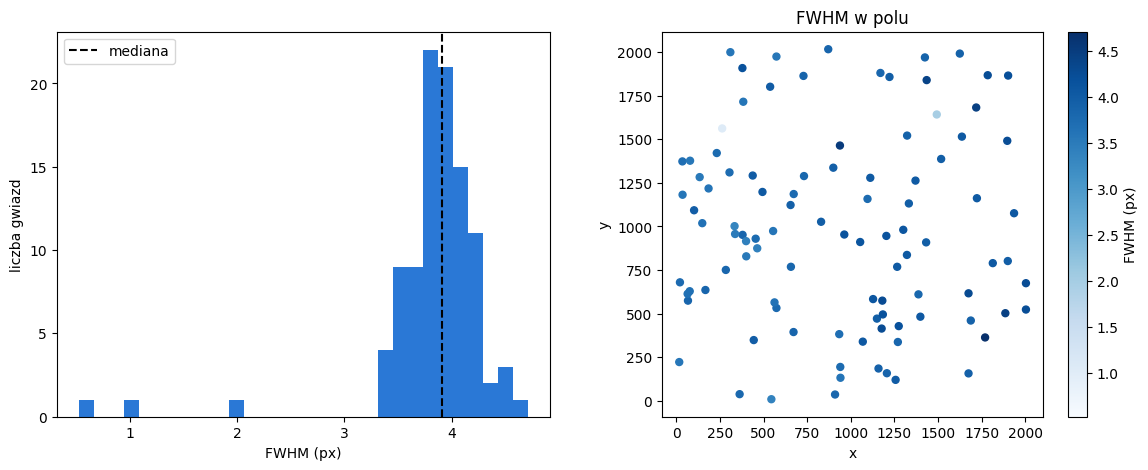

x,y,max_adu,box_mag,bkg,fwhm,fwhm_x,fwhm_y,ellipticity,theta,cpe,shape,ci
int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1054,911,15654.6376953125,11.153887697759782,23.415908813476562,4.117998530756206,4.390710658755116,3.8452864027572966,0.10852955291880106,-0.3253718839708597,0.036020774859552684,0.6108371266131848,0.883146813733406
1170,1880,13401.38671875,11.362699541838206,20.4407958984375,3.8410904716487586,3.85615712016771,3.8260238231298067,0.0601372856095127,-0.2424143395963103,0.03498775878494876,0.5162085538054646,0.8488009152942082
380,952,11066.9609375,11.69310399722044,17.08329963684082,3.858164150502655,3.753298718273272,3.963029582732038,0.13218176851289887,-0.45516028586168034,0.03828019875346805,0.5698172423668876,0.8677613883339933
729,1863,10399.0703125,11.557186687430354,18.05807399749756,3.862592704707735,3.845555277970279,3.879630131445191,0.09353586833976035,-0.5780091100090727,0.04356265874277728,0.6499384192895216,0.8562638496376502
1814,790,9075.5927734375,11.574056911260097,17.26838493347168,4.0438943488309,4.068751537300915,4.019037160360885,0.07570620088670543,0.09352479053145935,0.03860740697575398,0.6313500729521572,0.867720760472742
1266,769,5973.71435546875,12.213139536031525,14.345723628997803,4.028177151345776,4.241254213349748,3.8151000893418034,0.0813614118374616,-0.11563558351767966,0.03559825015618515,0.5776247240541792,0.8739188114054167
1222,1857,4040.453125,12.722107687043627,14.640024185180664,3.9616219181038472,4.2823344707229225,3.6409093654847724,0.07190919252409167,-0.32488036242070706,0.03733401755726425,0.5859368054717528,0.8538262005509765
1096,1158,3331.104736328125,12.811854282074457,10.406489372253418,3.7589103340612557,3.7606624194120064,3.757158248710505,0.08519173969182325,-0.17954755006013645,0.04425589476429075,0.6253095448266689,0.8384099981215414
401,829,3287.9013671875,13.120372229722898,10.740626811981201,3.5422289116277486,3.7088962629652213,3.3755615602902758,0.15745452059126086,-0.5468981141765692,0.05802920694933657,0.7281148392748945,0.8251247820523805


In [12]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].hist(ffs.stars["fwhm"], bins=30, color=C1)
axs[0].axvline(ffs.stats["frame"]["fwhm"], color="k", ls="--", label="mediana")
axs[0].set_xlabel("FWHM (px)"); axs[0].set_ylabel("liczba gwiazd"); axs[0].legend()
sc = axs[1].scatter(ffs.stars["x"], ffs.stars["y"], c=ffs.stars["fwhm"], cmap="Blues", s=25)
axs[1].set_aspect("equal"); axs[1].set_xlabel("x"); axs[1].set_ylabel("y"); axs[1].set_title("FWHM w polu")
fig.colorbar(sc, ax=axs[1], label="FWHM (px)")
plt.show()
ffs.stars[:10]

## 7. Wszystkie maski razem

exclude: ['lines', 'saturation'] | bad_mask: 283 px


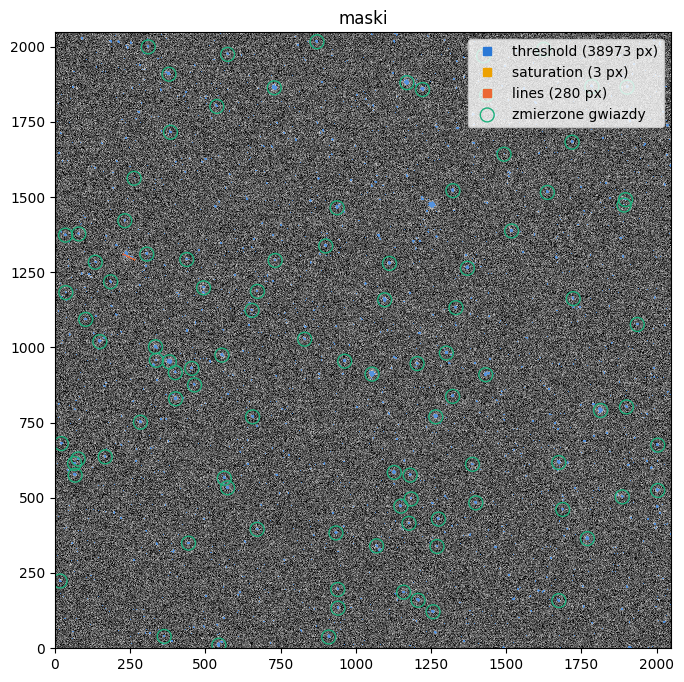

In [13]:
print("exclude:", sorted(ffs.exclude), "| bad_mask:", int(ffs.bad_mask().sum()), "px")

fig, ax = plt.subplots(figsize=(8, 8))
show(ax, image, "maski")
overlay(ax, ffs.masks["threshold"], C1, "threshold")
overlay(ax, ffs.masks["saturation"], C4, "saturation")
overlay(ax, ffs.masks["lines"], C2, "lines")
ax.scatter(ffs.coo[:, 1], ffs.coo[:, 0], s=100, facecolors="none", edgecolors=C3, label="zmierzone gwiazdy")
ax.legend(loc="upper right")
plt.show()

## 8. Maski z kalibracji

Maski złych kolumn, wierszy i pikseli robi się na zerach i darkach (`ffs_calibration.ipynb`). Na klatce naukowej
z tego samego detektora wystarczy je wpisać do `masks` i dopisać do `exclude`, zanim zaczniemy analizę:

```python
bits = fits.getdata("mask_zb08.fits")          # zapisana bitmaska
ffs = FFS(image)
ffs.masks["bad_columns"] = (bits & 1) > 0
ffs.exclude.add("bad_columns")
ffs.calc_frame_fwhm()                           # lub kroki 1-6 jak wyzej
```